RMSE X: 111.90
RMSE Y: 101.80
Tổng RMSE: 151.28


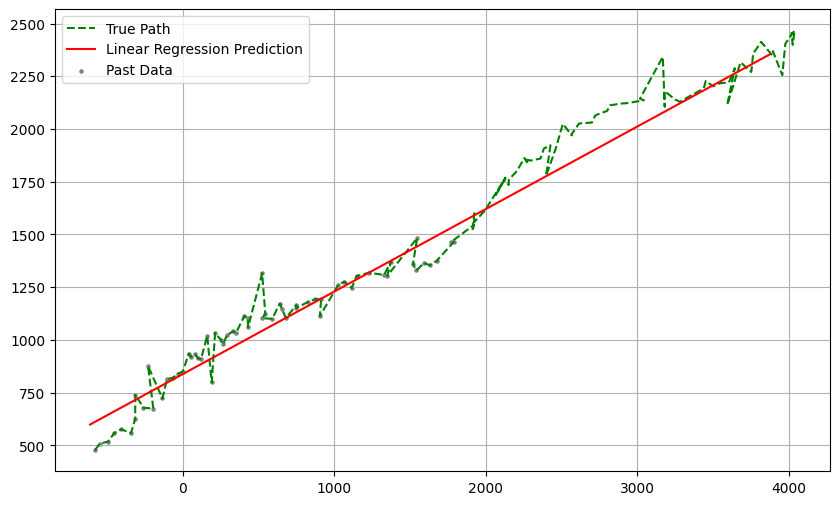

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 1. Đọc và tiền xử lý
df_past = pd.read_csv("data_3.csv")
df_val = pd.read_csv("data_3_after_and_before_t0.csv")

# Chuyển Descartes
df_past['x'] = df_past['range_m'] * np.cos(np.radians(df_past['bearing_deg']))
df_past['y'] = df_past['range_m'] * np.sin(np.radians(df_past['bearing_deg']))
df_val['x_true'] = df_val['range_m'] * np.cos(np.radians(df_val['bearing_deg']))
df_val['y_true'] = df_val['range_m'] * np.sin(np.radians(df_val['bearing_deg']))

# 2. Linear Regression trên tọa độ (t-x, t-y)
# Ta dùng time_s để học quy luật biến thiên của x và y
X_train = df_past[['time_s']].values
model_x = LinearRegression().fit(X_train, df_past['x'])
model_y = LinearRegression().fit(X_train, df_past['y'])

# 3. Dự báo trên tập Validation
X_val = df_val[['time_s']].values
pred_x = model_x.predict(X_val)
pred_y = model_y.predict(X_val)

# 4. Tính RMSE
rmse_x = np.sqrt(mean_squared_error(df_val['x_true'], pred_x))
rmse_y = np.sqrt(mean_squared_error(df_val['y_true'], pred_y))
rmse_final = np.sqrt(rmse_x**2 + rmse_y**2)

print(f"RMSE X: {rmse_x:.2f}")
print(f"RMSE Y: {rmse_y:.2f}")
print(f"Tổng RMSE: {rmse_final:.2f}")

# Plot để nhìn thấy sự lệch pha
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df_val['x_true'], df_val['y_true'], 'g--', label='True Path')
plt.plot(pred_x, pred_y, 'r-', label='Linear Regression Prediction')
plt.scatter(df_past['x'], df_past['y'], c='gray', s=5, label='Past Data')
plt.legend(); plt.grid(True); plt.show()

In [28]:
# --- THÊM LOGIC TÍNH AE TẠI CÁC MỐC 5s, 10s, 20s ---

# Danh sách các mốc thời gian cần kiểm tra
milestones = [5, 10, 20]

print(f"\n--- BÁO CÁO SAI SỐ TUYỆT ĐỐI (AE) TẠI CÁC MỐC ---")
for t in milestones:
    # Tìm index của dòng có thời gian gần với t nhất
    idx = (np.abs(df_val['time_s'] - t)).idxmin()
    
    # Lấy giá trị dự báo và thực tế
    x_pred_at_t = pred_x[idx]
    y_pred_at_t = pred_y[idx]
    x_true_at_t = df_val.loc[idx, 'x_true']
    y_true_at_t = df_val.loc[idx, 'y_true']
    
    # Tính AE (Euclidean distance giữa dự báo và thực tế)
    ae = np.sqrt((x_pred_at_t - x_true_at_t)**2 + (y_pred_at_t - y_true_at_t)**2)
    
    print(f"Thời điểm t = {t}s:")
    print(f"  - Sai số X: {abs(x_pred_at_t - x_true_at_t):.2f} m")
    print(f"  - Sai số Y: {abs(y_pred_at_t - y_true_at_t):.2f} m")
    print(f"  - AE (Khoảng cách): {ae:.2f} m")


--- BÁO CÁO SAI SỐ TUYỆT ĐỐI (AE) TẠI CÁC MỐC ---
Thời điểm t = 5s:
  - Sai số X: 103.53 m
  - Sai số Y: 8.90 m
  - AE (Khoảng cách): 103.91 m
Thời điểm t = 10s:
  - Sai số X: 114.53 m
  - Sai số Y: 133.14 m
  - AE (Khoảng cách): 175.63 m
Thời điểm t = 20s:
  - Sai số X: 45.88 m
  - Sai số Y: 153.44 m
  - AE (Khoảng cách): 160.15 m
